In [80]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score , confusion_matrix,classification_report
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

In [2]:
df = pd.read_csv(r"C:\Users\madha\Desktop\Projects\ML Project\Credit Card Fraud Detection\credit-card-fraud-ml\files\data\creditcard.csv")

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum().sum()

0

In [8]:
df.duplicated().sum()

1081

In [9]:
duplicate_percentage = df.duplicated().mean() * 100

duplicate_percentage

0.379555277784605

In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [12]:
class_counts = df["Class"].value_counts()

normal = class_counts[0]
fraud = class_counts[1]

print("Normal transactions:", normal)
print("Fraud transactions:", fraud)

Normal transactions: 284315
Fraud transactions: 492


In [13]:
fraud_percentage = fraud / len(df) * 100

print(f"Fraud percentage: {fraud_percentage:.4f}%")

Fraud percentage: 0.1727%


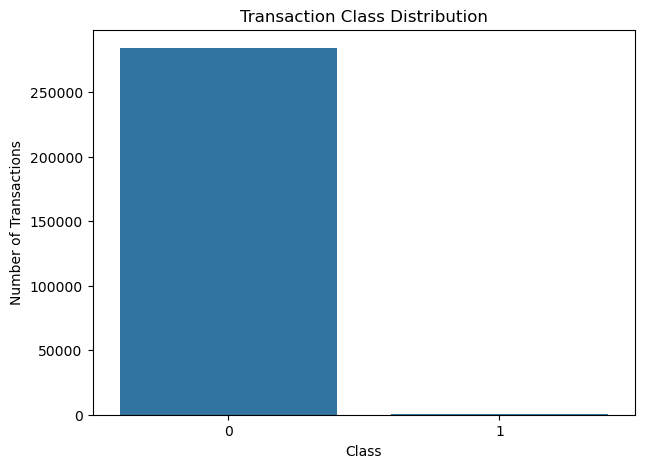

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(x="Class", data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

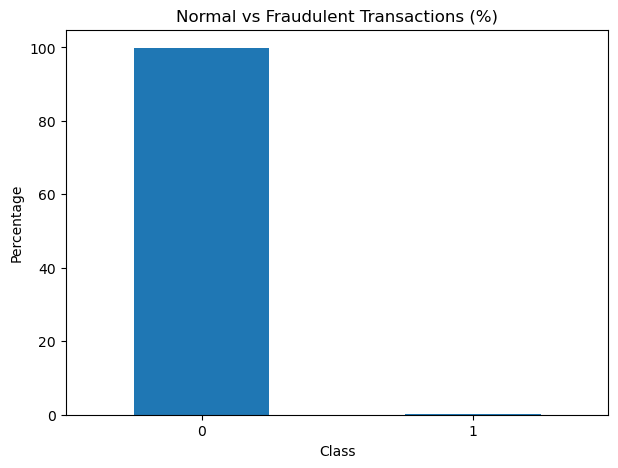

In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))

class_percentage.plot(kind="bar")

plt.title("Normal vs Fraudulent Transactions (%)")
plt.xlabel("Class")
plt.ylabel("Percentage")

plt.xticks(rotation=0)

plt.show()

In [16]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [17]:
print("Mean:", df["Amount"].mean())
print("Median:", df["Amount"].median())
print("Standard Deviation:", df["Amount"].std())
print("Skewness:", df["Amount"].skew())

Mean: 88.34961925093133
Median: 22.0
Standard Deviation: 250.1201092402221
Skewness: 16.977724453761024


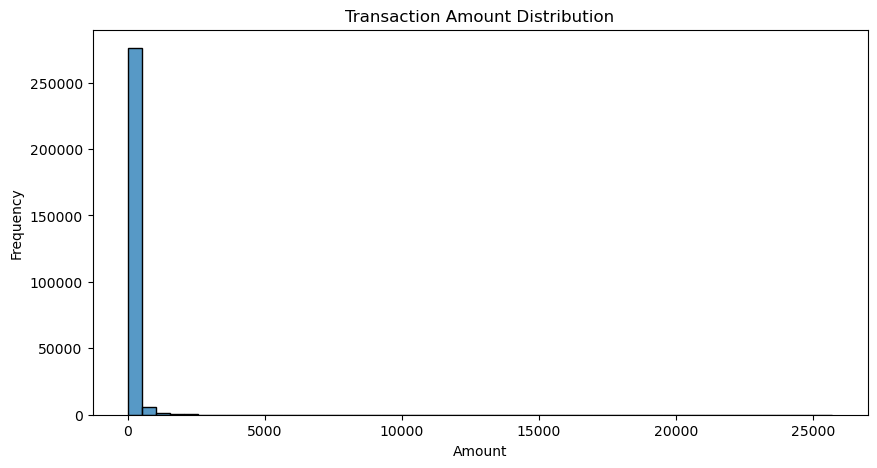

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

In [19]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [20]:
v_features = [f"V{i}" for i in range(1, 29)]

class_means = df.groupby("Class")[v_features].mean().T

class_means

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [21]:
mean_difference = class_means[1] - class_means[0]

mean_difference = mean_difference.sort_values()

mean_difference

V3    -7.045452
V14   -6.983787
V17   -6.677371
V12   -6.270225
V10   -5.686707
V7    -5.578368
V1    -4.780206
V16   -4.147110
V5    -3.156678
V9    -2.585589
V18   -2.250195
V6    -1.400155
V13   -0.109523
V24   -0.105312
V15   -0.093090
V23   -0.040378
V22    0.014073
V25    0.041521
V26    0.051738
V28    0.075798
V27    0.170870
V20    0.372964
V8     0.571623
V19    0.681837
V21    0.714823
V2     3.630049
V11    3.806749
V4     4.549889
dtype: float64

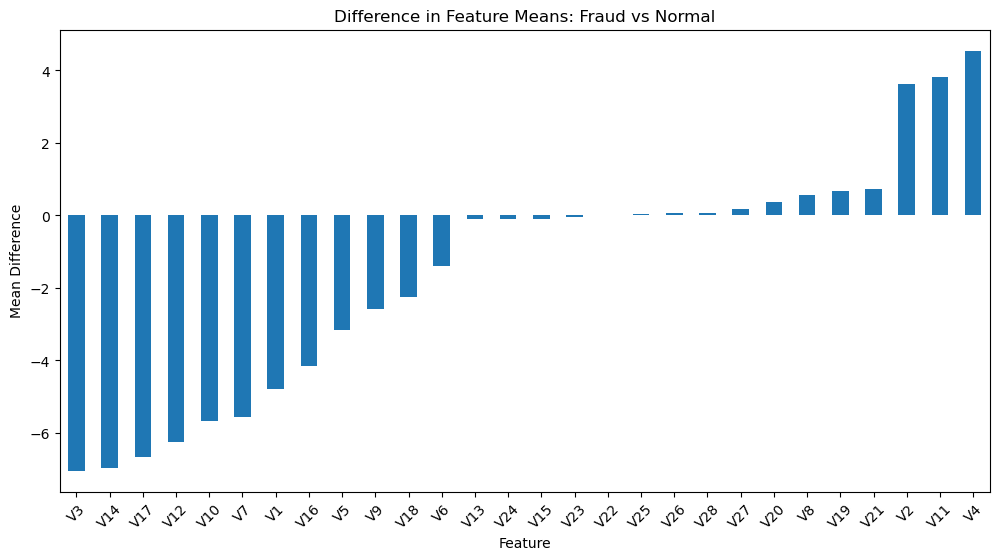

In [22]:
plt.figure(figsize=(12, 6))

mean_difference.plot(kind="bar")

plt.title("Difference in Feature Means: Fraud vs Normal")
plt.xlabel("Feature")
plt.ylabel("Mean Difference")

plt.xticks(rotation=45)

plt.show()

In [23]:
correlation = df.corr(numeric_only=True)["Class"].sort_values()

correlation

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

In [24]:
correlation_without_class = correlation.drop("Class")

correlation_without_class.abs().sort_values(ascending=False)

V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64

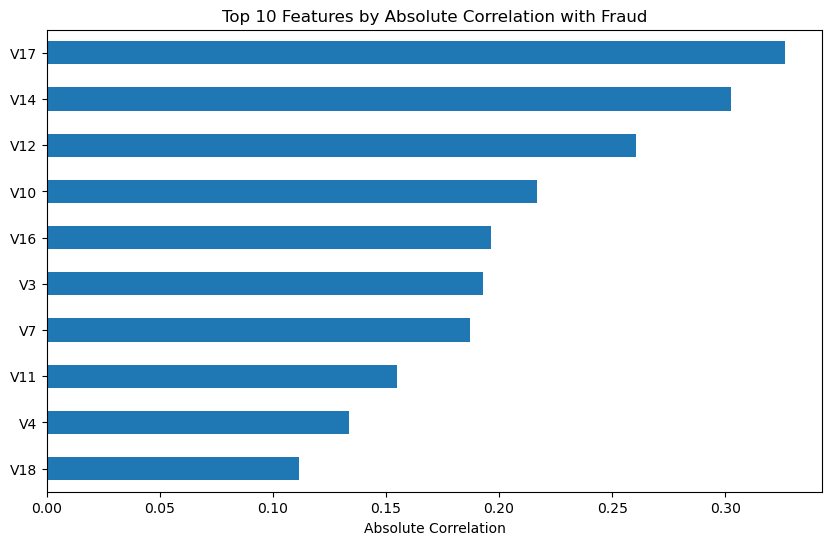

In [25]:
top_correlations = (
    correlation_without_class
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))

top_correlations.sort_values().plot(kind="barh")

plt.title("Top 10 Features by Absolute Correlation with Fraud")
plt.xlabel("Absolute Correlation")

plt.show()

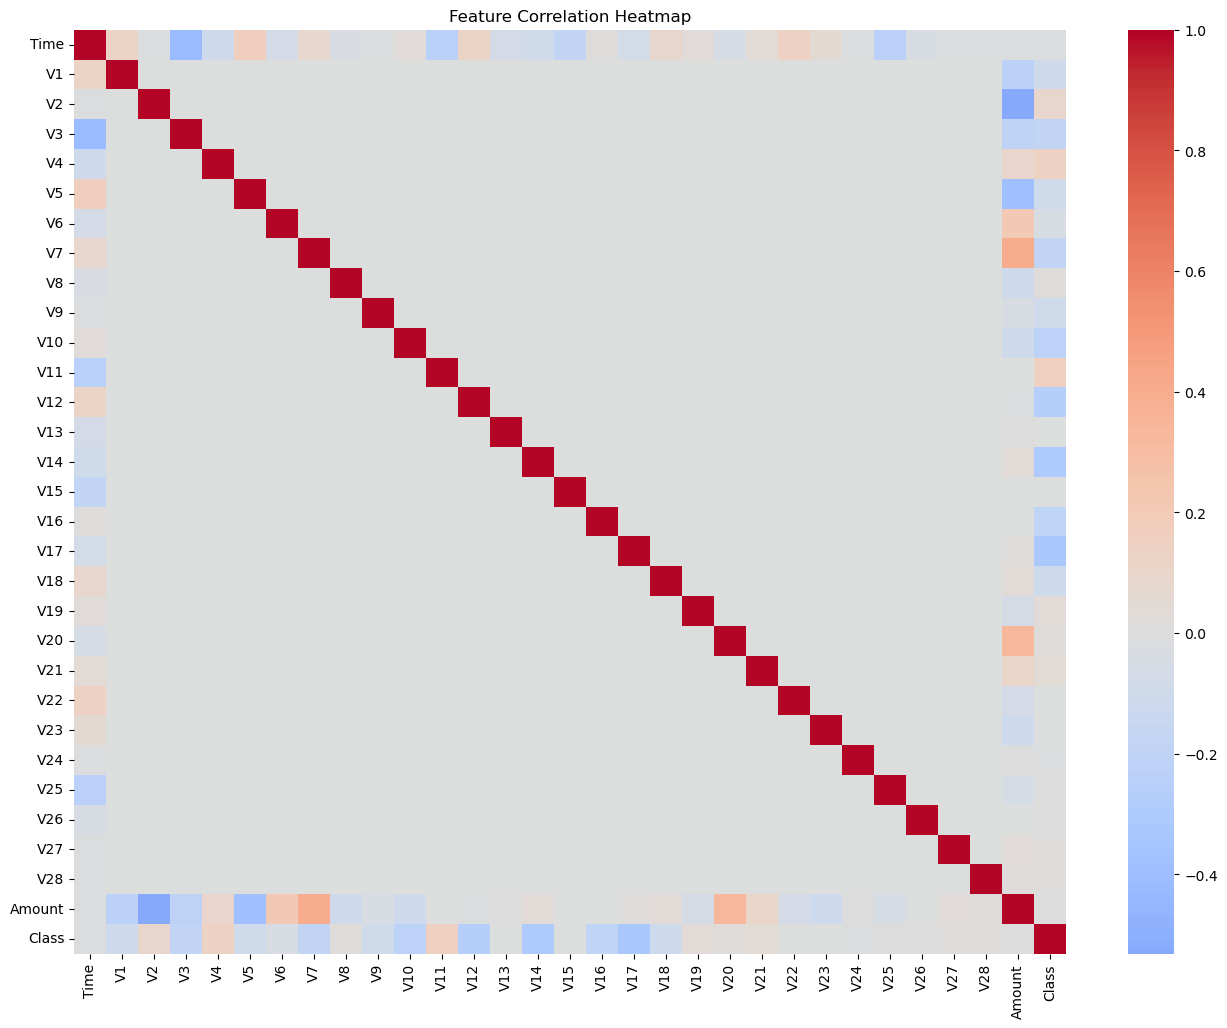

In [26]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [27]:
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 5.6
Q3: 77.16499999999999
IQR: 71.565
Lower Bound: -101.7475
Upper Bound: 184.5125


In [28]:
outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Number of outliers:", len(outliers))
print("Percentage of outliers:", len(outliers) / len(df) * 100)

Number of outliers: 31904
Percentage of outliers: 11.201971861646658


In [29]:
outliers["Class"].value_counts()

Class
0    31813
1       91
Name: count, dtype: int64

In [30]:
pd.crosstab(
    outliers["Class"],
    columns="count"
)

col_0,count
Class,
0,31813
1,91


In [31]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [32]:
df["Time"].head(10)

0    0.0
1    0.0
2    1.0
3    1.0
4    2.0
5    2.0
6    4.0
7    7.0
8    7.0
9    9.0
Name: Time, dtype: float64

In [33]:
df["Time_hours"] = df["Time"] / 3600

In [34]:
df["Time_hours"].describe()

count    284807.000000
mean         26.337183
std          13.191152
min           0.000000
25%          15.055972
50%          23.525556
75%          38.700139
max          47.997778
Name: Time_hours, dtype: float64

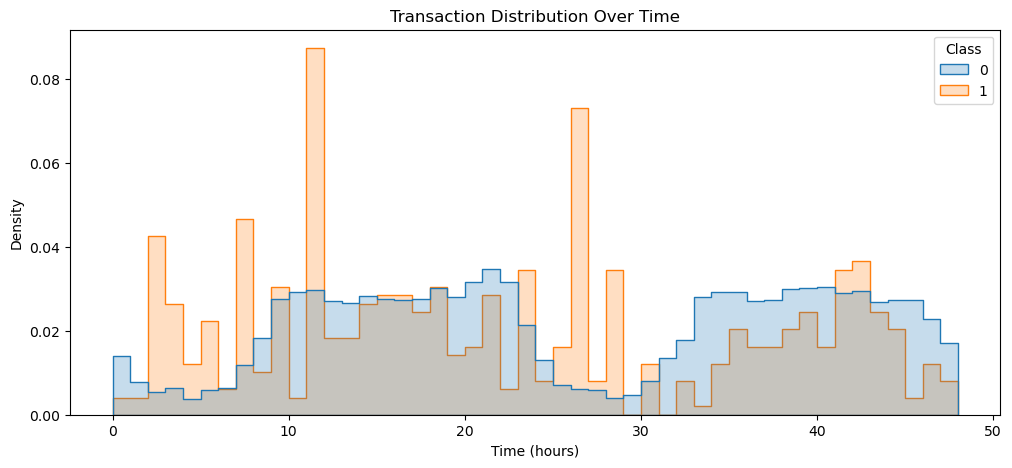

In [35]:
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time_hours",
    hue="Class",
    bins=48,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time (hours)")
plt.ylabel("Density")

plt.show()

In [36]:
df["Time_hour_bin"] = (df["Time"] // 3600).astype(int)

In [37]:
fraud_by_hour = (
    df[df["Class"] == 1]
    .groupby("Time_hour_bin")
    .size()
)

fraud_by_hour

Time_hour_bin
0      2
1      2
2     21
3     13
4      6
5     11
6      3
7     23
8      5
9     15
10     2
11    43
12     9
13     9
14    13
15    14
16    14
17    12
18    15
19     7
20     8
21    14
22     3
23    17
24     4
25     8
26    36
27     4
28    17
30     6
32     4
33     1
34     6
35    10
36     8
37     8
38    10
39    12
40     8
41    17
42    18
43    12
44    10
45     2
46     6
47     4
dtype: int64

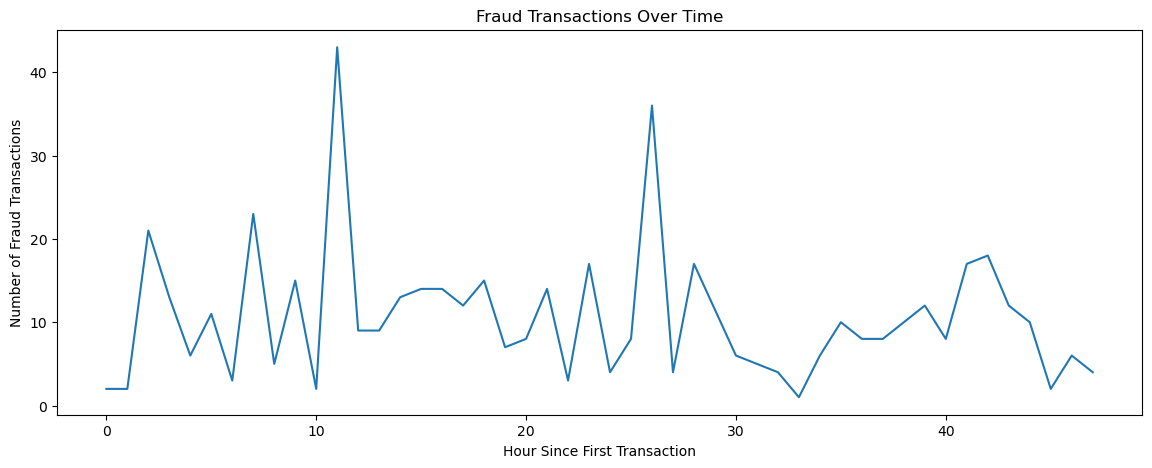

In [38]:
plt.figure(figsize=(14, 5))

fraud_by_hour.plot()

plt.title("Fraud Transactions Over Time")
plt.xlabel("Hour Since First Transaction")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [39]:
hourly_class = (
    df.groupby(["Time_hour_bin", "Class"])
    .size()
    .unstack(fill_value=0)
)

hourly_class.head()

Class,0,1
Time_hour_bin,,
0,3961,2
1,2215,2
2,1555,21
3,1808,13
4,1076,6


In [40]:
hourly_class.columns = ["Normal", "Fraud"]

hourly_class.head()

,Normal,Fraud
Time_hour_bin,,
0,3961,2
1,2215,2
2,1555,21
3,1808,13
4,1076,6


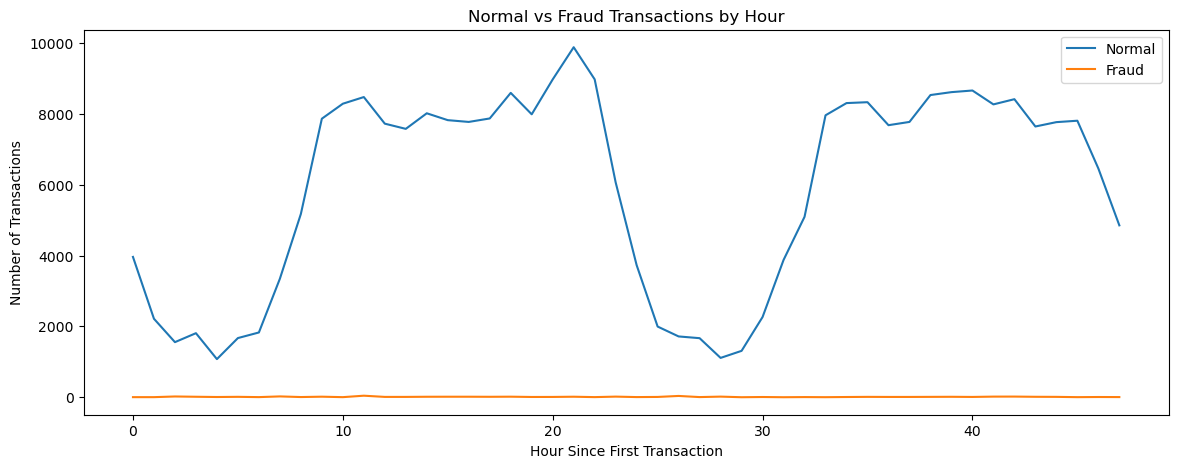

In [41]:
hourly_class.plot(
    figsize=(14, 5)
)

plt.title("Normal vs Fraud Transactions by Hour")
plt.xlabel("Hour Since First Transaction")
plt.ylabel("Number of Transactions")

plt.show()

In [42]:
top_features = ["V17", "V14", "V12", "V10", "V16", "V3", "V7", "V11", "V4", "V18"]

In [43]:
df.groupby("Class")[top_features].mean().T

Class,0,1
V17,0.011535,-6.665836
V14,0.012064,-6.971723
V12,0.010832,-6.259393
V10,0.009824,-5.676883
V16,0.007164,-4.139946
V3,0.012171,-7.033281
V7,0.009637,-5.568731
V11,-0.006576,3.800173
V4,-0.007860,4.542029
V18,0.003887,-2.246308


In [44]:
df.groupby("Class")[top_features].median().T

Class,0,1
V17,-0.064833,-5.302949
V14,0.051947,-6.729720
V12,0.141679,-5.502530
V10,-0.091872,-4.578825
V16,0.067377,-3.549795
V3,0.182158,-5.075257
V7,0.041138,-3.034402
V11,-0.034923,3.586218
V4,-0.022405,4.177147
V18,-0.002787,-1.664346


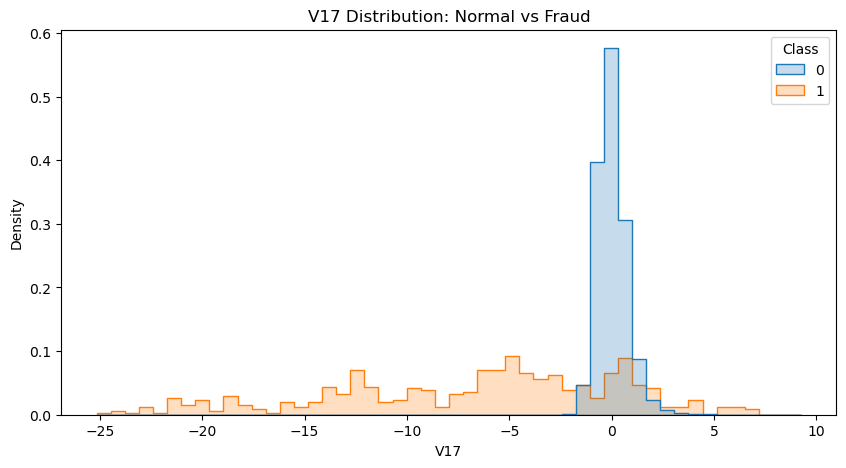

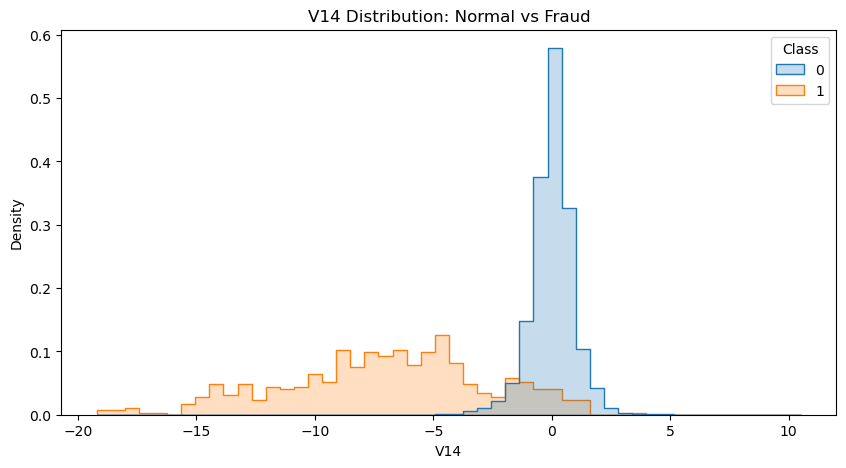

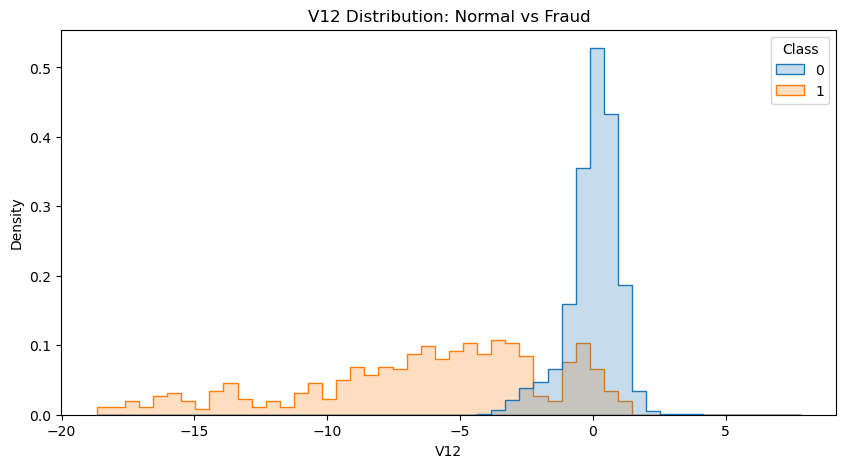

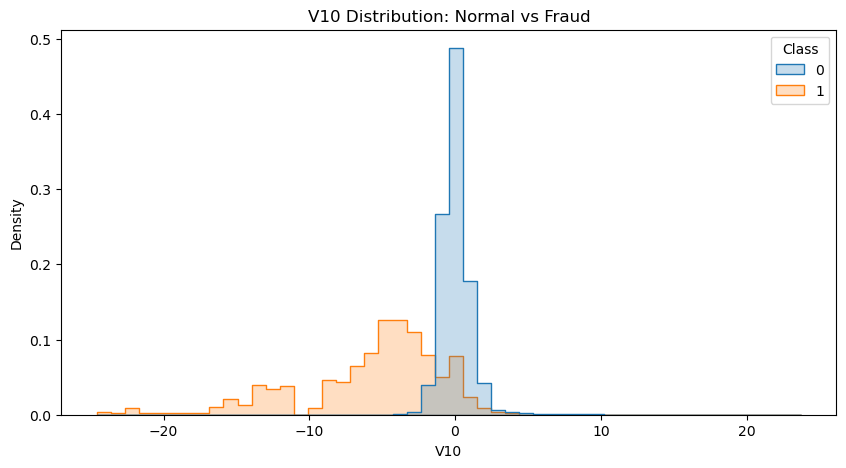

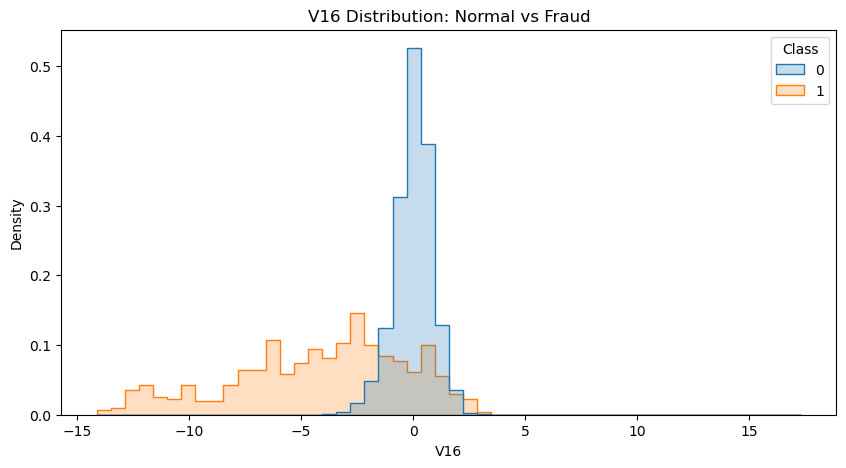

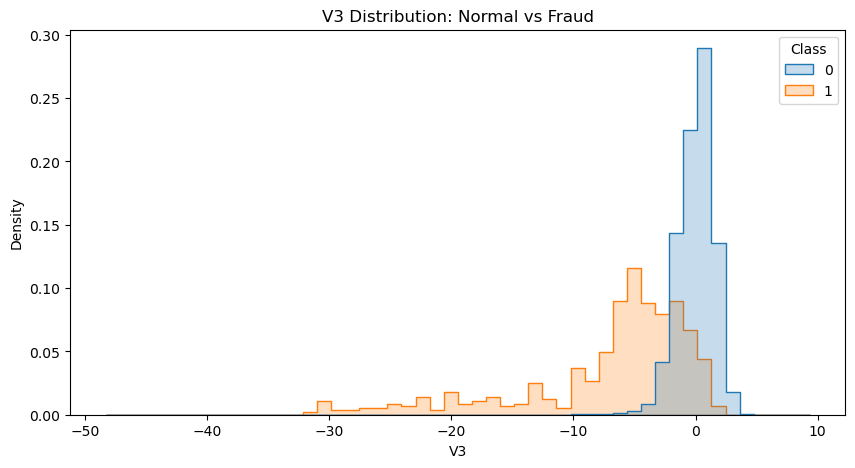

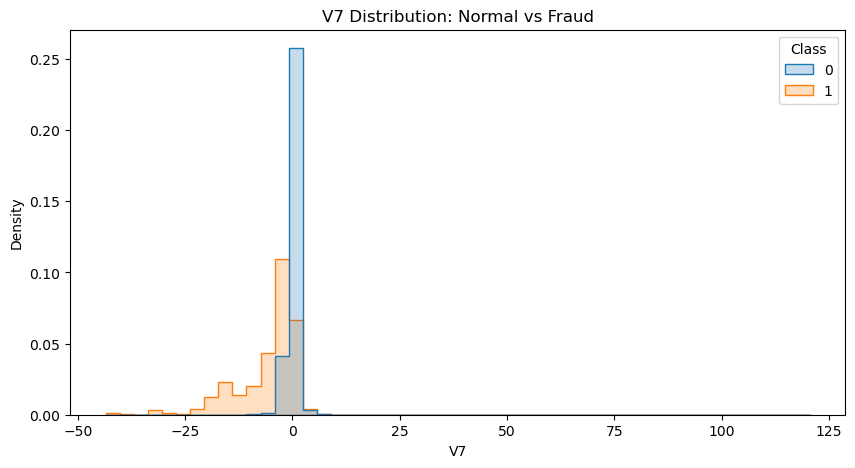

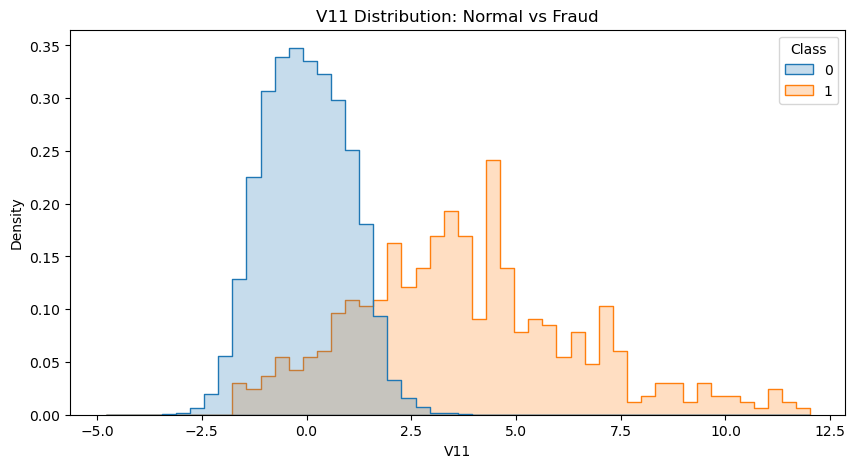

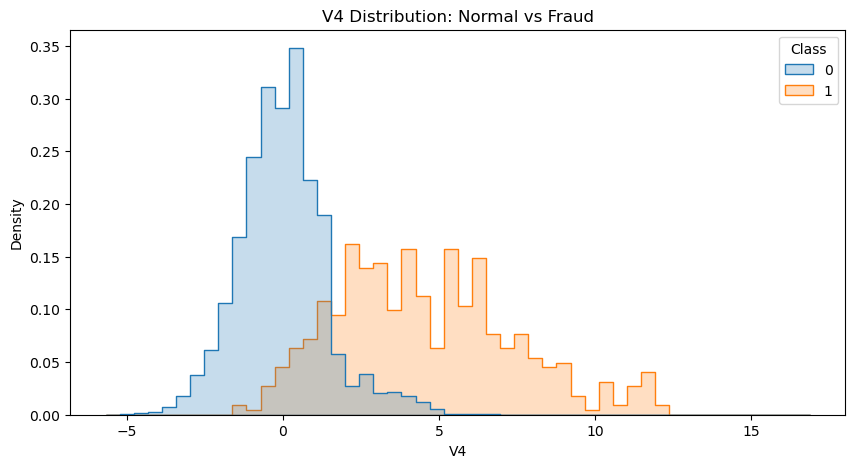

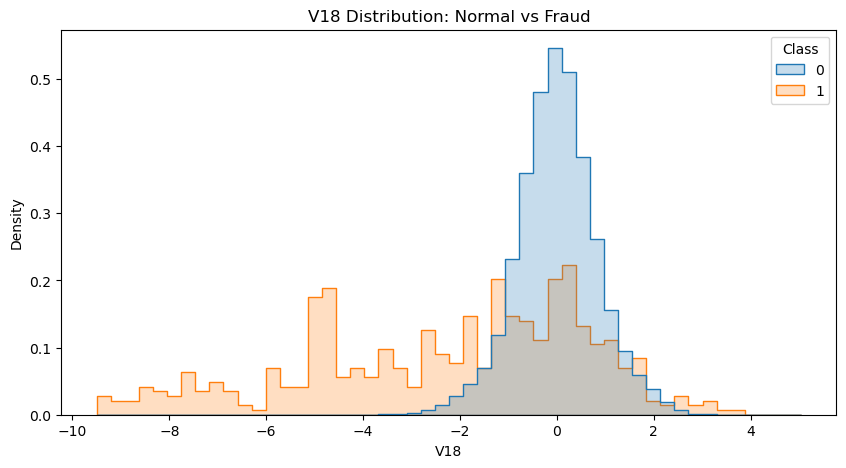

In [45]:
top_features = ["V17", "V14", "V12", "V10", "V16", "V3", "V7", "V11", "V4", "V18"]

for feature in top_features:
    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{feature} Distribution: Normal vs Fraud")
    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.show()

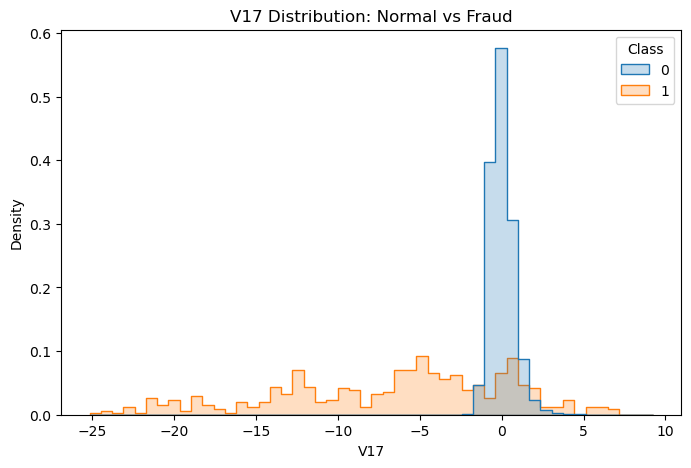

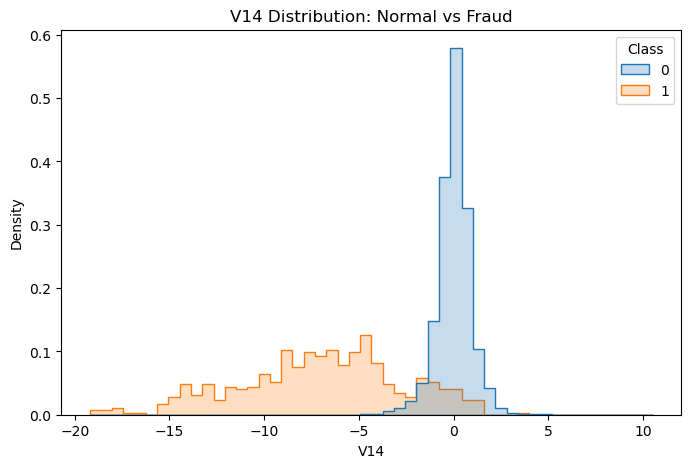

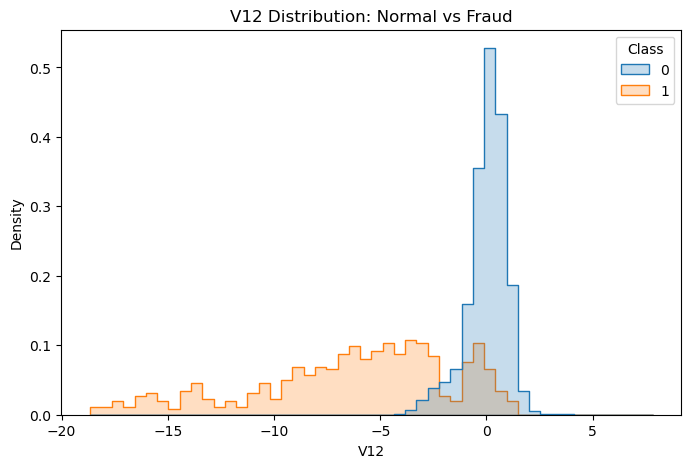

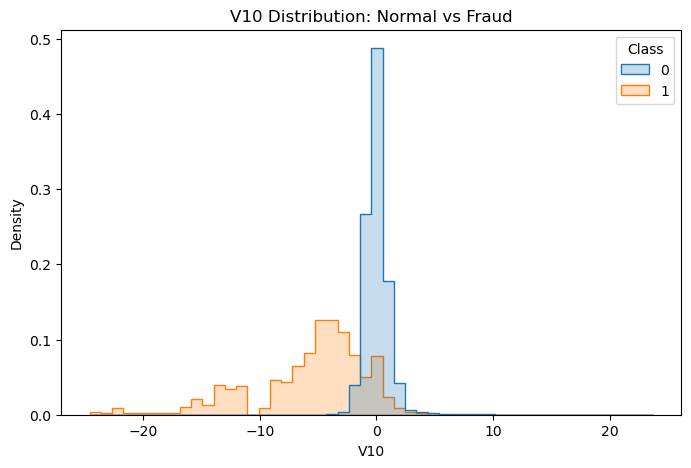

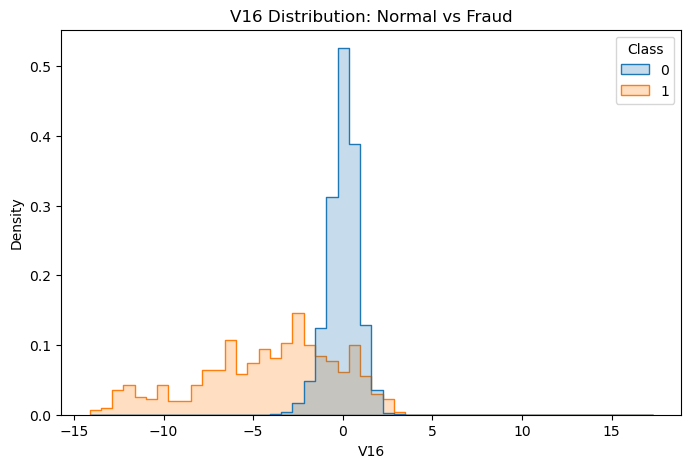

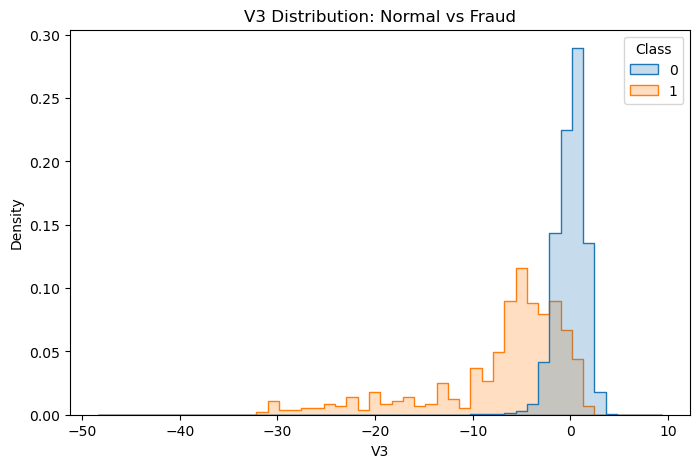

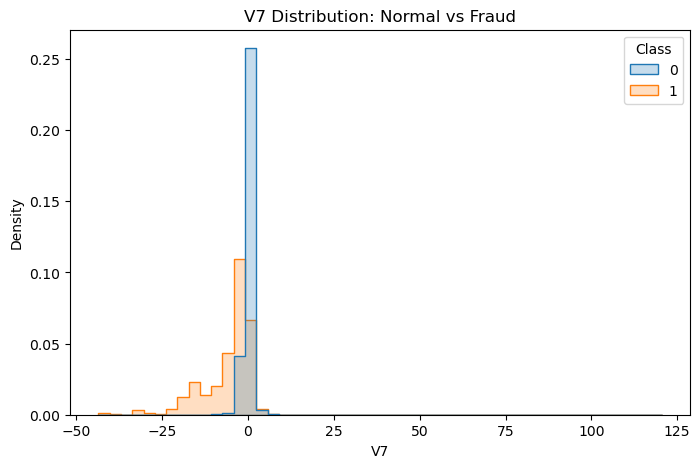

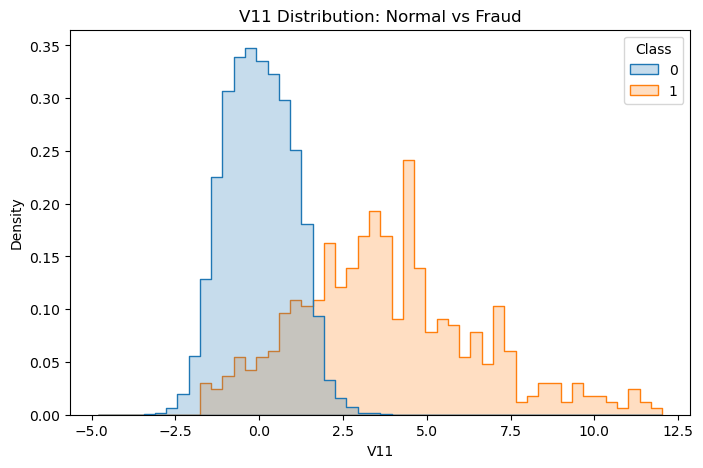

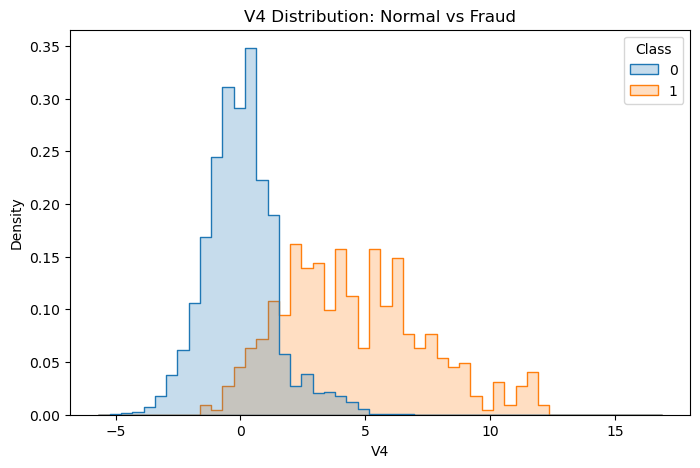

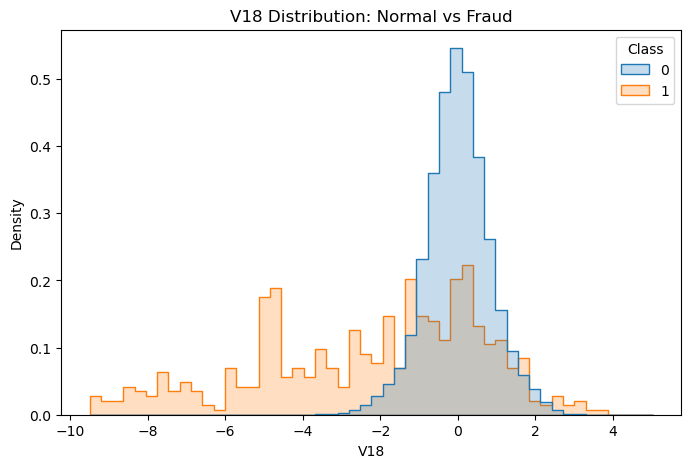

In [46]:
for feature in top_features:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{feature} Distribution: Normal vs Fraud")
    plt.xlabel(feature)
    plt.ylabel("Density")

    plt.show()

In [47]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 32)
y shape: (284807,)


In [48]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Time_hours,Time_hour_bin
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.000000,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.000000,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.000278,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.000278,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.000556,0


In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining fraud cases:", y_train.sum())
print("Testing fraud cases:", y_test.sum())

Training set: (227845, 32)
Testing set: (56962, 32)

Training fraud cases: 394
Testing fraud cases: 98


In [53]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [54]:
print(X_train[["Time", "Amount"]].describe())

               Time        Amount
count  2.278450e+05  2.278450e+05
mean  -1.407707e-16 -2.020811e-17
std    1.000002e+00  1.000002e+00
min   -1.998073e+00 -3.516894e-01
25%   -8.561495e-01 -3.291944e-01
50%   -2.122647e-01 -2.639429e-01
75%    9.366285e-01 -4.262209e-02
max    1.640549e+00  1.021170e+02


In [55]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nTraining fraud cases:", y_train.sum())
print("Testing fraud cases:", y_test.sum())

Training set: (227845, 32)
Testing set: (56962, 32)

Training fraud cases: 394
Testing fraud cases: 98


In [57]:
X = X.drop(columns=["Time_hour_bin"])

print("Features used for ML:")
print(X.columns.tolist())
print("\nNumber of features:", X.shape[1])

Features used for ML:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time_hours']

Number of features: 31


In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining fraud cases:", y_train.sum())
print("Testing fraud cases:", y_test.sum())

Training set: (227845, 31)
Testing set: (56962, 31)

Training fraud cases: 394
Testing fraud cases: 98


In [59]:
from collections import Counter

print("Training class distribution:")
print(Counter(y_train))

print("\nTesting class distribution:")
print(Counter(y_test))

Training class distribution:
Counter({0: 227451, 1: 394})

Testing class distribution:
Counter({0: 56864, 1: 98})


In [62]:
baseline_model = LogisticRegression(
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)
print("Baseline model trained successfully.")

Baseline model trained successfully.


In [63]:
y_pred = baseline_model.predict(X_test)

print("Predictions completed.")
print("Total predictions:", len(y_pred))
print("Predicted fraud cases:", y_pred.sum())

Predictions completed.
Total predictions: 56962
Predicted fraud cases: 1475


In [64]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Classification metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Individual metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

Confusion Matrix:
[[55479  1385]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962

Precision: 0.061
Recall: 0.9184
F1 Score: 0.1144


In [65]:
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Probability predictions completed.")
print("Minimum probability:", y_prob.min())
print("Maximum probability:", y_prob.max())

Probability predictions completed.
Minimum probability: 1.7216006984964923e-29
Maximum probability: 1.0


In [67]:
thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

results = []

for threshold in thresholds:
    y_threshold = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Predicted Fraud": y_threshold.sum(),
        "Precision": precision_score(y_test, y_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_threshold, zero_division=0),
        "F1 Score": f1_score(y_test, y_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Predicted Fraud,Precision,Recall,F1 Score
0,0.1,11468,0.008110,0.948980,0.016082
1,0.2,5628,0.016347,0.938776,0.032134
2,0.3,3298,0.027289,0.918367,0.053004
3,0.4,2139,0.042076,0.918367,0.080465
4,0.5,1475,0.061017,0.918367,0.114431
5,0.6,1022,0.087084,0.908163,0.158929
6,0.7,730,0.121918,0.908163,0.214976
7,0.8,546,0.159341,0.887755,0.270186
8,0.9,357,0.243697,0.887755,0.382418


In [69]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_index = f1_scores.argmax()

best_threshold = thresholds[best_index]
best_precision = precision[best_index]
best_recall = recall[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", round(best_threshold, 4))
print("Best Precision:", round(best_precision, 4))
print("Best Recall:", round(best_recall, 4))
print("Best F1 Score:", round(best_f1, 4))

Best Threshold: 1.0
Best Precision: 0.8333
Best Recall: 0.8163
Best F1 Score: 0.8247


In [70]:
y_threshold = (y_prob >= best_threshold).astype(int)

print("Best Threshold:", best_threshold)
print("Predicted fraud cases:", y_threshold.sum())
print("Actual fraud cases:", y_test.sum())

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_threshold))

print("\nClassification Report:")
print(classification_report(y_test, y_threshold, zero_division=0))

print("Precision:", round(precision_score(y_test, y_threshold, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_threshold, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_threshold, zero_division=0), 4))

Best Threshold: 0.9999999430431473
Predicted fraud cases: 96
Actual fraud cases: 98

Confusion Matrix:
[[56848    16]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.8333
Recall: 0.8163
F1 Score: 0.8247


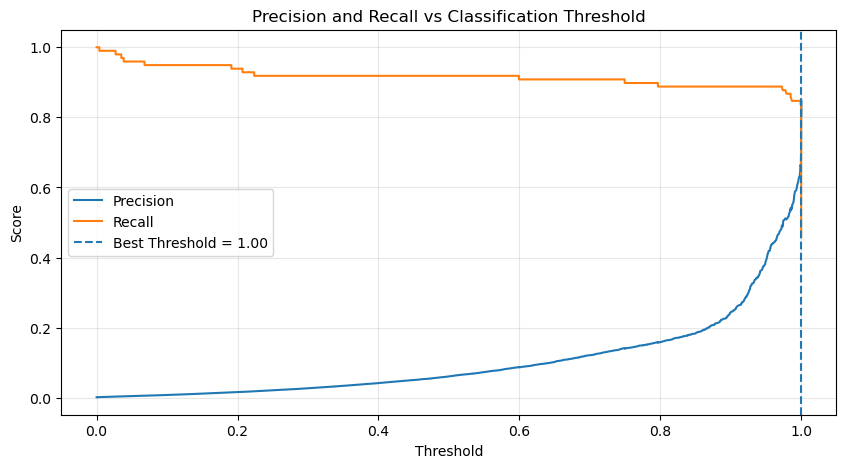

In [72]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(10, 5))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Classification Threshold")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [74]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [75]:
y_rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed.")
print("Total predictions:", len(y_rf_pred))
print("Predicted fraud cases:", y_rf_pred.sum())

Random Forest predictions completed.
Total predictions: 56962
Predicted fraud cases: 85


In [77]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_rf_pred, zero_division=0))

print("Precision:", round(precision_score(y_test, y_rf_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_rf_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_rf_pred, zero_division=0), 4))

Confusion Matrix:
[[56856     8]
 [   21    77]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.91      0.79      0.84        98

    accuracy                           1.00     56962
   macro avg       0.95      0.89      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.9059
Recall: 0.7857
F1 Score: 0.8415


In [78]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_rf_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_rf_pred, zero_division=0)
    ]
})

model_results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.061017,0.918367,0.114431
1,Random Forest,0.905882,0.785714,0.841530


In [81]:
gb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

gb_model.fit(X_train, y_train)

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [82]:
y_gb_pred = gb_model.predict(X_test)

print("Gradient Boosting predictions completed.")
print("Total predictions:", len(y_gb_pred))
print("Predicted fraud cases:", y_gb_pred.sum())

Gradient Boosting predictions completed.
Total predictions: 56962
Predicted fraud cases: 153


In [83]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_gb_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_gb_pred, zero_division=0))

print("Precision:", round(precision_score(y_test, y_gb_pred, zero_division=0), 4))
print("Recall:", round(recall_score(y_test, y_gb_pred, zero_division=0), 4))
print("F1 Score:", round(f1_score(y_test, y_gb_pred, zero_division=0), 4))

Confusion Matrix:
[[56788    76]
 [   21    77]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.79      0.61        98

    accuracy                           1.00     56962
   macro avg       0.75      0.89      0.81     56962
weighted avg       1.00      1.00      1.00     56962

Precision: 0.5033
Recall: 0.7857
F1 Score: 0.6135


In [84]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_rf_pred, zero_division=0),
        precision_score(y_test, y_gb_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_rf_pred, zero_division=0),
        recall_score(y_test, y_gb_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_rf_pred, zero_division=0),
        f1_score(y_test, y_gb_pred, zero_division=0)
    ]
})

model_results = model_results.round(4)

model_results

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.0610,0.9184,0.1144
1,Random Forest,0.9059,0.7857,0.8415
2,Gradient Boosting,0.5033,0.7857,0.6135


In [86]:
import joblib
import os

os.makedirs(r"C:\Users\madha\Desktop\Projects\ML Project\Credit Card Fraud Detection\credit-card-fraud-ml\files\models", exist_ok=True)

joblib.dump(rf_model, "../models/random_forest_fraud_model.pkl")

print("Random Forest model saved successfully.")
print("Path: ../models/random_forest_fraud_model.pkl")

Random Forest model saved successfully.
Path: ../models/random_forest_fraud_model.pkl


In [87]:
feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    "../models/feature_names.pkl"
)

print("Feature names saved successfully.")
print("Number of features:", len(feature_names))
print("Features:", feature_names)

Feature names saved successfully.
Number of features: 31
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Time_hours']


In [88]:
import joblib
import os

model_path = "../models/random_forest_fraud_model.pkl"
features_path = "../models/feature_names.pkl"

loaded_model = joblib.load(model_path)
loaded_features = joblib.load(features_path)

print("Model loaded successfully.")
print("Feature list loaded successfully.")
print("Number of features:", len(loaded_features))
print("Model type:", type(loaded_model).__name__)

Model loaded successfully.
Feature list loaded successfully.
Number of features: 31
Model type: RandomForestClassifier


In [89]:
# Load saved model and feature names
model = joblib.load("../models/random_forest_fraud_model.pkl")
feature_names = joblib.load("../models/feature_names.pkl")

# Take one transaction from the test dataset
sample_transaction = X_test.iloc[[0]]

# Prediction
prediction = model.predict(sample_transaction)[0]

# Fraud probability
probability = model.predict_proba(sample_transaction)[0][1]

print("Prediction:", prediction)
print("Fraud Probability:", round(probability, 4))

if prediction == 1:
    print("Result: FRAUD")
else:
    print("Result: LEGITIMATE")

Prediction: 0
Fraud Probability: 0.0
Result: LEGITIMATE


In [90]:
# Find a known fraud transaction from the test set

fraud_index = y_test[y_test == 1].index[0]

fraud_transaction = X_test.loc[[fraud_index]]

prediction = model.predict(fraud_transaction)[0]
probability = model.predict_proba(fraud_transaction)[0][1]

print("Actual Class: FRAUD")
print("Prediction:", prediction)
print("Fraud Probability:", round(probability, 4))

if prediction == 1:
    print("Result: FRAUD")
else:
    print("Result: LEGITIMATE")

Actual Class: FRAUD
Prediction: 1
Fraud Probability: 0.9798
Result: FRAUD
